# Introduction

In [232]:
users = [
{ "id": 0, "name": "Hero" },
{ "id": 1, "name": "Dunn" },
{ "id": 2, "name": "Sue" },
{ "id": 3, "name": "Chi" },
{ "id": 4, "name": "Thor" },
{ "id": 5, "name": "Clive" },
{ "id": 6, "name": "Hicks" },
{ "id": 7, "name": "Devin" },
{ "id": 8, "name": "Kate" },
{ "id": 9, "name": "Klein" }
]

friendship_pairs =  [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4),
(4, 5), (5, 6), (5, 7), (6, 8), (7, 8), (8, 9)]



In this example, the tuple $(0,1)$ indicates that the data scientist with id0 (Hero) and the data scientist with id1 (Dunn) are friends. The network is illustrated. 

![description](/Users/bmart231/DS/Notebooks/01-Introduction/figure-1-1-datasciencester-network.png)

Having friendships represented as a list of pairs is not the easiest way to work with them. To find all friendships for user 1, you have to iterate over every pair looking for pairs containing 1. If you had a lot of pairs, this would take a long time. 

Instead we create a ```dict``` where the keys are user ```ids``` and the values are lists of friends ```ids```. 


We'll still have to look at every pair to create the ```dict```, but we only have to do that once, and we'll get cheap lookups after that:


In [233]:
# Initialize the dict with an empty list of each user id:
friendships = {user["id"]: [] for user in users}

# Loop over the friendship pairs to populate it:
for i, j in friendship_pairs:
    friendships[i].append(j)
    friendships[j].append(i)


Now that we have the friendship in a ```dict```, we can easily ask questions of our graph, like "What's the average number of connections?"

First we find the *total* number of connections, by summing up the lengths of all the ```friends``` lists:


In [234]:
def number_of_friends(user):
    """How many friends does _user_ have?"""
    
    user_id = user["id"]
    friend_ids = friendships[user_id]
    return len(friend_ids)

total_connections = sum(number_of_friends(user)
for user in users)

print(total_connections) # should be 24

24


Now we can just divide the number of users: 


In [235]:
num_users = len(users)
avg_connections = total_connections / num_users # 24 / 10 == 2.4

print(avg_connections) 


2.4


It's also easy to find the most connected people - they're the people who have the largest number of friends. 

Since there aren't very many users, we can simply sort them from **most friends** to **least friends**:


In [236]:
# Create a list (user_id, number_of_friends). 
num_friend_by_id = [(user["id"], number_of_friends(user)) for user in users]

num_friend_by_id.sort(                              # Sort the list
    key = lambda id_and_friends: id_and_friends[1], # by num_friends
    reverse=True)                                   # largest to smallest

# Each pair is (user_id, num_friends):
# [(1, 3), (2, 3), (3, 3), (5, 3), (8, 3),
# (0, 2), (4, 2), (6, 2), (7, 2), (9, 1)]

One way to think of what we've done is as a way of identifying people who are somehow central to the network. **Degree Centrality**. 

![description](/Users/bmart231/DS/Notebooks/01-Introduction/Degree_Centrality.png)




## People you may know

Suggest that users might know the friends of their friends. Write code to iterate over thier friends and collect the friend's friends:


In [237]:
def foaf_ids_bad(user):
    """foaf is short of "friend of a friend" """
    return [foaf_id
            for friend_id in friendships[user["id"]]
            for foaf_id in friendships[friend_id]]
    
print(foaf_ids_bad(users[0]))    

[0, 2, 3, 0, 1, 3]


We can see that it produces 0 twice, since Hero is indeed friends with both of his friends. It includes users 1 and 2, although they are both friends with Hero already. And it includes user 3 twice, as Chi is reachable through two different friends:

In [238]:
print(friendships[0])
print(friendships[1])
print(friendships[2])

[1, 2]
[0, 2, 3]
[0, 1, 3]


Knowing that people are friends of friends in mulitple ways leads to interesting formations. Instead we can produce *count* of mutual friends. And we should exclude people already known to the user:


In [239]:
from collections import Counter

def friends_of_friends(user):
    user_id = user["id"]
    return Counter(
        foaf_id
        for friends_id in friendships[user_id]  # For each of my friends
        for foaf_id in friendships[friends_id]  # find their friends 
        if foaf_id != user_id                   # who aren't me
        and foaf_id not in friendships[user_id] # and aren't my friends
    )    
    
print(friends_of_friends(users[3]))

Counter({0: 2, 5: 1})


This correctly tells Chi (```id```3) that she has two mutual friends with Hero (```id```0) but only one mutual friend with Clive (```id```5)

## Meting users with similar interests

After asking around you get dataset as a list of pairs (``user_id, interst``):



In [240]:
interests = [
(0, "Hadoop"), (0, "Big Data"), (0, "HBase"), (0, "Java"),
(0, "Spark"), (0, "Storm"), (0, "Cassandra"),
(1, "NoSQL"), (1, "MongoDB"), (1, "Cassandra"), (1, "HBase"),
(1, "Postgres"), (2, "Python"), (2, "scikit-learn"), (2, "scipy"),
(2, "numpy"), (2, "statsmodels"), (2, "pandas"), (3, "R"), (3, "Python"),
(3, "statistics"), (3, "regression"), (3, "probability"),
(4, "machine learning"), (4, "regression"), (4, "decision trees"),
(4, "libsvm"), (5, "Python"), (5, "R"), (5, "Java"), (5, "C++"),
(5, "Haskell"), (5, "programming languages"), (6, "statistics"),
(6, "probability"), (6, "mathematics"), (6, "theory"),
(7, "machine learning"), (7, "scikit-learn"), (7, "Mahout"),
(7, "neural networks"), (8, "neural networks"), (8, "deep learning"),
(8, "Big Data"), (8, "artificial intelligence"), (9, "Hadoop"),
(9, "Java"), (9, "MapReduce"), (9, "Big Data")
]

For example, Hero (``id0``) has no friends in common with Klein (``id9``), but they share similar interest in Java and big data. 

To build function that finds users with a certain interest:

In [241]:
def data_scientist_who_like(target_interest):
    """Find the ids of all the users who like the target interests"""
    return[user_id
           for user_id, user_interest in interests if user_interest == target_interest]

print(data_scientist_who_like("Big Data"))

[0, 8, 9]


This works, but it has to examine the whole list of interest for every search. If we have a lot of users and interests, we're better off building an index from interests to users:

In [242]:
from collections import defaultdict

# Keys are interests, values are lists of user_ids with that interest 
user_ids_by_interest = defaultdict(list)

for user_id, interest in interests:
    user_ids_by_interest[interest].append(user_id)
    
    

And another from users to interest:

In [243]:
# Keys are user_ids, values are lists of interests for that user_id. 
interests_by_user_id = defaultdict(list)

for user_id, interest in interests:
    interests_by_user_id[user_id].append(interest)

This makes it easy to find who has the most interest in common with a given user:
- Iterate over the user's interest
- For each interest, iterate over the other users with that interest
- Keep count of how many times we see each other user

Code:

In [244]:
def most_common_interst_with(user):
    return Counter(
        interested_user_id
        for interest in interests_by_user_id[user["id"]]
        for interested_user_id in user_ids_by_interest[interest]
        if interested_user_id != user["id"]
    )
    
    
print(most_common_interst_with(users[0]))

Counter({9: 3, 1: 2, 8: 1, 5: 1})


## Salaries and Experience

Dataset includes users ```salary``` (in dollars) and ```tenure``` as a data scientist (in years). 

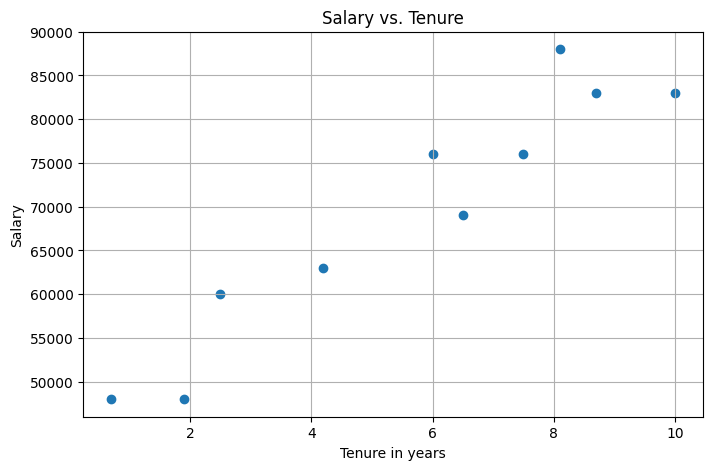

In [245]:
# Dataset
salaries_and_tenures = [(83000, 8.7), (88000, 8.1),
(48000, 0.7), (76000, 6),
(69000, 6.5), (76000, 7.5),
(60000, 2.5), (83000, 10),
(48000, 1.9), (63000, 4.2)]


import matplotlib.pyplot as plt

# Separate salaries and tenures
salaries = [salary for salary, tenure in salaries_and_tenures]
tenures = [tenure for salary, tenure in salaries_and_tenures]
plt.figure(figsize=(8, 5))
plt.scatter(tenures, salaries)
plt.xlabel("Tenure in years")
plt.ylabel("Salary")
plt.title("Salary vs. Tenure")
plt.grid(True)
plt.show()


We can see that people with more experience tend to earn more. Let's look at average salary for each tenure:

In [246]:
# Keys are years, values are lists of the salaries of each tenure
salary_by_tenure = defaultdict(list)

for salary, tenure in salaries_and_tenures:
    salary_by_tenure[tenure].append(salary)

# Keys are years, each value is average salary for that tenure
average_salary_by_tenure = {
    tenure: sum(salaries) / len(salaries)
    for tenure, salaries in salary_by_tenure.items()}

print(average_salary_by_tenure)

{8.7: 83000.0, 8.1: 88000.0, 0.7: 48000.0, 6: 76000.0, 6.5: 69000.0, 7.5: 76000.0, 2.5: 60000.0, 10: 83000.0, 1.9: 48000.0, 4.2: 63000.0}


It is more useful to bucket the tenures:

In [247]:
def tenure_bucket(tenure):
    if tenure < 2:
        return "less than one"
    elif tenure < 5:
        return " between two and five"
    else:
        return "more than five"

Group together the salaries corresponding to each bucket:

In [248]:
# Keys are tenure buckets, values are lists of salaries for that bucket.
salary_by_tenure_bucket = defaultdict(list)

for salary, tenure in salaries_and_tenures:
    bucket = tenure_bucket(tenure)
    salary_by_tenure_bucket[bucket].append(salary)

And finally compute the average salary for each group:

In [249]:
# Keys are tenure buckets, values are average salary for that bucket. 
average_salary_by_bucket = {
    tenure_bucket: sum(salaries) / len(salaries)
    for tenure_bucket, salaries in salary_by_tenure_bucket.items()
}

print(average_salary_by_bucket, sep='\n')


{'more than five': 79166.66666666667, 'less than one': 48000.0, ' between two and five': 61500.0}


## Paids Accounts

Correspondence between years of experience and paids accounts:

0.7 paid
1.9 unpaid
2.5 paid
4.2 unpaid
6.0 unpaid
6.5 unpaid
7.5 unpaid
8.1 unpaid
8.7 paid
10.0 paid


Users with very few and very many years of experience tend to pay; users with average amunts of experience don't. 


In [250]:
def predict_paid_or_unpaid(years_experience):
    if years_experience < 3.0:
        return "paid"
    elif years_experience < 8.5:
        return "unpaid"
    else: 
        return "paid"

## Topics of Interest 

Dataset about what topics users are most interested in: 

In [251]:
interests = [
(0, "Hadoop"), (0, "Big Data"), (0, "HBase"), (0, "Java"),
(0, "Spark"), (0, "Storm"), (0, "Cassandra"),
(1, "NoSQL"), (1, "MongoDB"), (1, "Cassandra"), (1, "HBase"),
(1, "Postgres"), (2, "Python"), (2, "scikit-learn"), (2, "scipy"),
(2, "numpy"), (2, "statsmodels"), (2, "pandas"), (3, "R"), (3, "Python"),
(3, "statistics"), (3, "regression"), (3, "probability"),
(4, "machine learning"), (4, "regression"), (4, "decision trees"),
(4, "libsvm"), (5, "Python"), (5, "R"), (5, "Java"), (5, "C++"),
(5, "Haskell"), (5, "programming languages"), (6, "statistics"),
(6, "probability"), (6, "mathematics"), (6, "theory"),
(7, "machine learning"), (7, "scikit-learn"), (7, "Mahout"),
(7, "neural networks"), (8, "neural networks"), (8, "deep learning"),
(8, "Big Data"), (8, "artificial intelligence"), (9, "Hadoop"),
(9, "Java"), (9, "MapReduce"), (9, "Big Data")
]

One simple way to find popular interests is to count the words:
1. Lowercase each interest (since different users may or may not capitalize their interests). 
2. Split it into words
3. Count the results

In [252]:
words_and_counts = Counter(word
                           for user, interest in interests
                           for word in interest.lower().split())
# This makes it easy to list out the words that occur more than once:
for word, count in words_and_counts.most_common():
    if count > 1:
        print(word, count)

big 3
data 3
java 3
python 3
learning 3
hadoop 2
hbase 2
cassandra 2
scikit-learn 2
r 2
statistics 2
regression 2
probability 2
machine 2
neural 2
networks 2
